# Distribuciones de Probabilidad

## Objetivo

En esta etapa del proyecto se analizan las distribuciones de probabilidad que describen el comportamiento de las variables relacionadas con los hábitos saludables de los estudiantes universitarios.

El objetivo es identificar si las variables se ajustan mejor a distribuciones discretas o continuas, justificar la elección de dichas distribuciones y calcular probabilidades asociadas a eventos relevantes.

## Variables analizadas

Variables continuas:
- Horas de sueño
- Horas de ejercicio
- Promedio académico (GPA)

Variables discretas:
- Consumo de comida rápida semanal
- Nivel de estrés

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
data = pd.read_csv("/content/drive/MyDrive/habitos_saludables_estudiantes.csv")
data

,edad,genero,horas_sueno,horas_ejercicio,comida_rapida_semana,estres,Prom_academico
0,18,Masculino,6.9,2.0,0,6,5.98
1,25,Femenino,5.6,1.2,2,10,6.31
2,28,Femenino,7.6,0.7,1,8,4.88
3,20,Masculino,6.3,1.2,3,3,5.20
4,28,Femenino,6.1,3.1,4,10,5.49
...,...,...,...,...,...,...,...
145,27,Masculino,5.7,3.0,3,10,5.59
146,27,Masculino,6.9,6.5,3,2,6.40
147,29,Masculino,7.7,3.6,1,3,6.12
148,26,Masculino,5.0,3.3,2,1,5.60


Distribución Normal (variable continua)

Vamos a analizar horas de sueño, que generalmente se aproxima a una distribución normal.

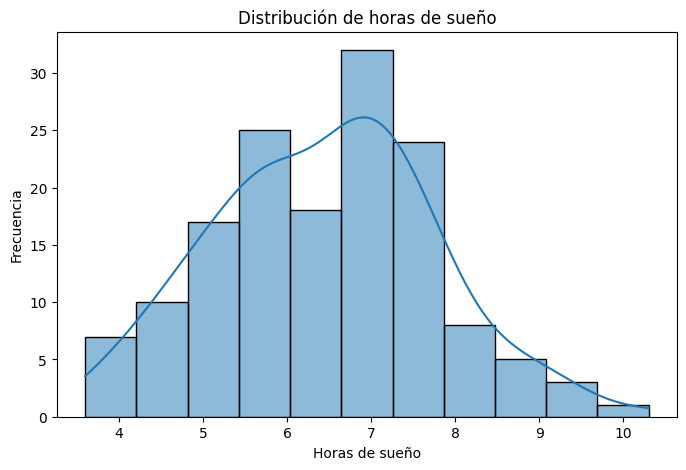

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(data["horas_sueno"], kde=True)

plt.title("Distribución de horas de sueño")
plt.xlabel("Horas de sueño")
plt.ylabel("Frecuencia")

plt.show()

In [12]:
#Calcular parámetros de la distribución
media_sueno = data["horas_sueno"].mean()
std_sueno = data["horas_sueno"].std()

media_sueno, std_sueno

(np.float64(6.448666666666666), 1.3071171551435983)

In [13]:
#Probabilidad usando distribución normal
prob = stats.norm.cdf(5, loc=media_sueno, scale=std_sueno)

print("Probabilidad de dormir menos de 5 horas:", prob)

Probabilidad de dormir menos de 5 horas: 0.13386799999730092


In [ ]:
#Distribución Poisson (variable discreta)

## Distribución de Poisson

La distribución de Poisson se utiliza para modelar la cantidad de veces que ocurre un evento en un intervalo fijo.

En este caso puede utilizarse para modelar el número de comidas rápidas consumidas por semana.

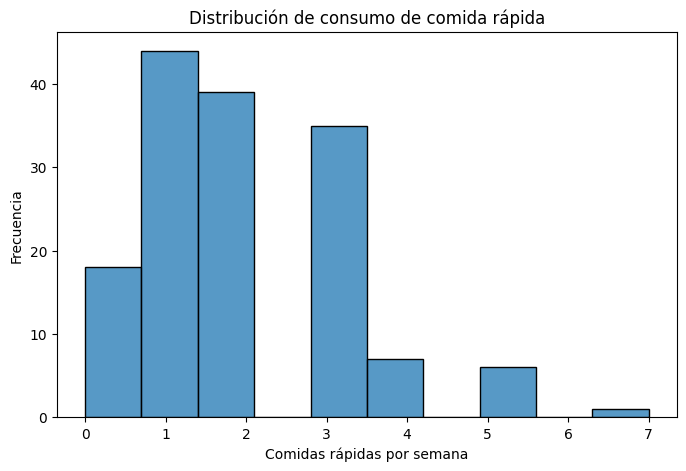

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(data["comida_rapida_semana"], bins=10)

plt.title("Distribución de consumo de comida rápida")
plt.xlabel("Comidas rápidas por semana")
plt.ylabel("Frecuencia")

plt.show()

In [15]:
#Parámetro lambda de Poisson
lambda_fastfood = data["comida_rapida_semana"].mean()

lambda_fastfood

np.float64(1.9466666666666668)

In [16]:
#Probabilidad Poisson:Probabilidad de que un estudiante consuma exactamente 3 comidas rápidas por semana
prob_poisson = stats.poisson.pmf(3, lambda_fastfood)

print("Probabilidad:", prob_poisson)

Probabilidad: 0.17550800731708835


In [ ]:
#Distribución Binomial

## Distribución Binomial

La distribución binomial se utiliza cuando un experimento tiene dos posibles resultados.

En este caso podemos analizar el evento:

Dormir lo suficiente (≥ 7 horas) o no.

In [17]:
data["duerme_bien"] = data["horas_sueno"] >= 7
p = data["duerme_bien"].mean()
p

np.float64(0.36666666666666664)

In [18]:
#Probabilidad binomial:Probabilidad de que 5 de 10 estudiantes duerman bien
prob_binomial = stats.binom.pmf(5, 10, p)

print("Probabilidad:", prob_binomial)

Probabilidad: 0.17018427315000773


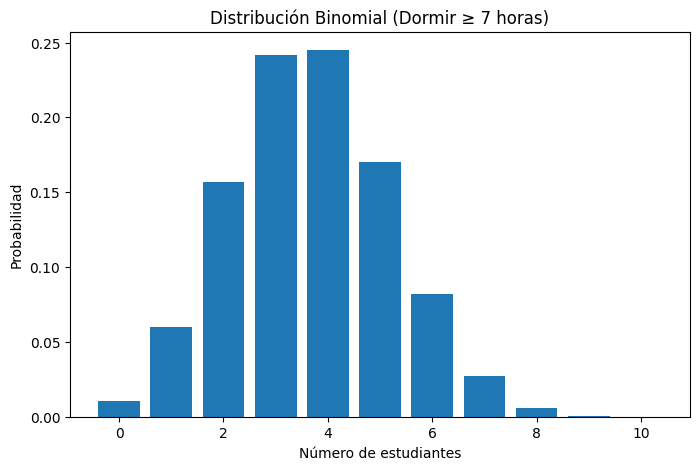

In [19]:
#Gráfico de distribución binomial
x = np.arange(0,11)

probabilidades = stats.binom.pmf(x, 10, p)

plt.figure(figsize=(8,5))
plt.bar(x, probabilidades)

plt.title("Distribución Binomial (Dormir ≥ 7 horas)")
plt.xlabel("Número de estudiantes")
plt.ylabel("Probabilidad")

plt.show()

## Conclusiones

El análisis de las variables permitió identificar diferentes tipos de distribuciones de probabilidad dentro del dataset.

Las horas de sueño se aproximan a una distribución normal, lo que es común en variables fisiológicas continuas.

El consumo de comida rápida semanal puede modelarse mediante una distribución de Poisson, ya que representa la frecuencia de ocurrencia de un evento en un intervalo fijo.

Finalmente, se utilizó una distribución binomial para modelar la probabilidad de que un cierto número de estudiantes duerman al menos 7 horas por noche.

Estas distribuciones permiten modelar matemáticamente el comportamiento de las variables y sirven como base para aplicar técnicas de inferencia estadística en las siguientes etapas del proyecto.